In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [3]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from optax.losses import huber_loss
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph

# print(jax.devices("gpu"))
print(jax.default_backend())

gpu


# configuration

In [4]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

# CAMELS

In [5]:
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2"

SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0"


out_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    # i_snapshots=[-2,-1],
    # i_snapshots=range(1, 33+4, 8),
    i_snapshots=range(1, 33+4, 4),
    return_hydro=True,
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  11%|█         | 1/9 [00:01<00:12,  1.53s/it]

Found 6 duplicate gas particle IDs


finding unique gas particle indices:  22%|██▏       | 2/9 [00:07<00:27,  3.97s/it]

Found 368 duplicate gas particle IDs


...

finding unique gas particle indices:  89%|████████▉ | 8/9 [00:40<00:05,  5.42s/it]

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 9/9 [00:45<00:00,  5.10s/it]


There are 15915287 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 9/9 [01:42<00:00, 11.36s/it]


In [6]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

In [7]:
@nnx.jit(static_argnames=("loss_fn",))
def train_step(model, optimizer, loss_fn):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

losses = []

In [8]:
# latent_init = cic_read(cic_paint(jnp.zeros(mesh_shape), gas_poss[0]), gas_poss[0])
# latent_init = jnp.expand_dims(latent_init, axis=-1)

# latent_init = jnp.ones((parts_per_dim**3,1))
# latent_init = jnp.ones((parts_per_dim**3,8))

latent_init = None

edges = graph.get_edges(gas_poss, scales, k=4)

def solve_ode_diffrax(model, architecture):
    res = diffeqsolve(
            terms=ODETerm(hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, dm_model=None, gas_model=model, gas_architecture=architecture, precomputed_edges=edges)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.02,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
        )

    res = res.ys

    return res

# loss

### CAMELS ground truth

In [9]:
# per-particle reference
ref_pos = jnp.stack(gas_poss, axis=0)
ref_vel = jnp.stack(gas_vels, axis=0)

# field-level reference
gas_mass = cosmo.Omega_b / (cosmo.Omega_b + cosmo.Omega_c)
ref_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

# power spectrum reference
vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
_, ref_cls = vpower_spectrum(ref_rho)

vcross_correlation_separate = jax.vmap(
    lambda field_a, field_b:
        cross_correlation_coefficients(
            compensate_cic(field_a),
            compensate_cic(field_b),
            boxsize=np.array([25.0] * 3),
            kmin=np.pi / 25.0,
            dk=2 * np.pi / 25.0,
        )
)
vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

### particle-level

In [10]:
def mse_fn(model, architecture):
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]
    gas_vels = res[3]

    delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_pos**2, axis=-1)
    pos_loss = jnp.mean(pos_loss)

    return pos_loss

def huber_fn(model, architecture):
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]
    gas_vels = res[3]

    delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(huber_loss(delta_pos), axis=-1)
    pos_loss = jnp.mean(pos_loss)

    return pos_loss

def dead_zone_fn(model, architecture):
    res = solve_ode_diffrax(model, architecture)
    gas_poss = res[2]
    gas_vels = res[3]

    delta_pos = ((gas_poss - ref_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_pos**2, axis=-1)
    pos_loss = jnp.where(pos_loss < 1/mesh_per_dim, 0.0, pos_loss)
    pos_loss = jnp.mean(pos_loss)

    return pos_loss

# architecture

### MLP

In [25]:
with_latent = True

model = MLP(
    d_in=5, 
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    dropout_rate=0.01,
    rngs=nnx.Rngs(0)
)
architecture = "mlp"

# training

In [26]:
total_steps = 300
# learning_rate = 1e-3
learning_rate = optax.cosine_decay_schedule(
    init_value=1e-3, 
    decay_steps=total_steps, 
    alpha=0.1
)
clip_norm = 1

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []

# loss_fn = lambda model: mse_fn(model, architecture)
# loss_type = "mse"

# loss_fn = lambda model: huber_fn(model, architecture)
# loss_type = "huber"

loss_fn = lambda model: dead_zone_fn(model, architecture)
loss_type = "dead zone"

  0%|          | 0/300 [00:00<?, ?it/s]

dark matter, gas and latent
Using learned pressure force
No latent variable
dark matter, gas and latent
Using learned pressure force
No latent variable
dark matter, gas and latent
Using learned pressure force
No latent variable


2025-03-12 22:38:02.594160: E external/xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 4s:

  %negate.61 = f32[9,262144,3]{2,1,0} negate(f32[9,262144,3]{2,1,0} %constant.142)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-03-12 22:38:03.974166: E external/xla/xla/service/slow_operation_alarm.cc:133] The operation took 5.380075978s
Constant folding an instruction is taking > 4s:

  %negate.61 = f32[9,262144,3]{2,1,0} negate(f32[9,262144,3]{2,1,0} %constant.142)

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some gu

[None]

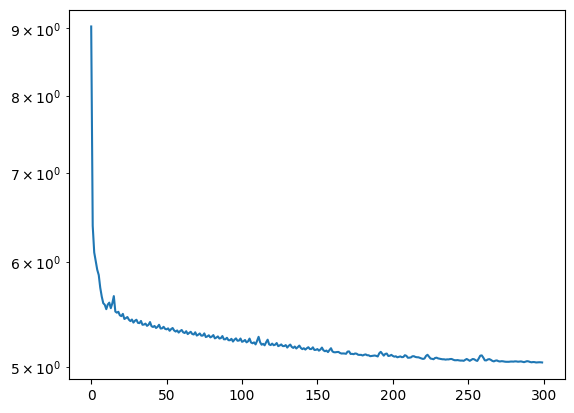

In [27]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss = train_step(model, optimizer, loss_fn)

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

# run the simulation

In [28]:
og_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo)

og_res = diffeqsolve(
        terms=ODETerm(og_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

og_dm_poss, og_dm_vels, og_gas_poss, og_gas_vels = og_res.ys

dark matter and gas
dark matter and gas
dark matter and gas


In [29]:
nn_ode = hpm.get_hpm_network_ode_fn(mesh_per_dim, cosmo, gas_model=model)

nn_res = diffeqsolve(
        terms=ODETerm(nn_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        # y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]),
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

# nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels = nn_res.ys
nn_dm_poss, nn_dm_vels, nn_gas_poss, nn_gas_vels, nn_gas_mass = nn_res.ys

dark matter, gas and latent
Using learned pressure force
No latent variable
dark matter, gas and latent
Using learned pressure force
No latent variable
dark matter, gas and latent
Using learned pressure force
No latent variable


100%|██████████| 9/9 [00:17<00:00,  1.93s/it]


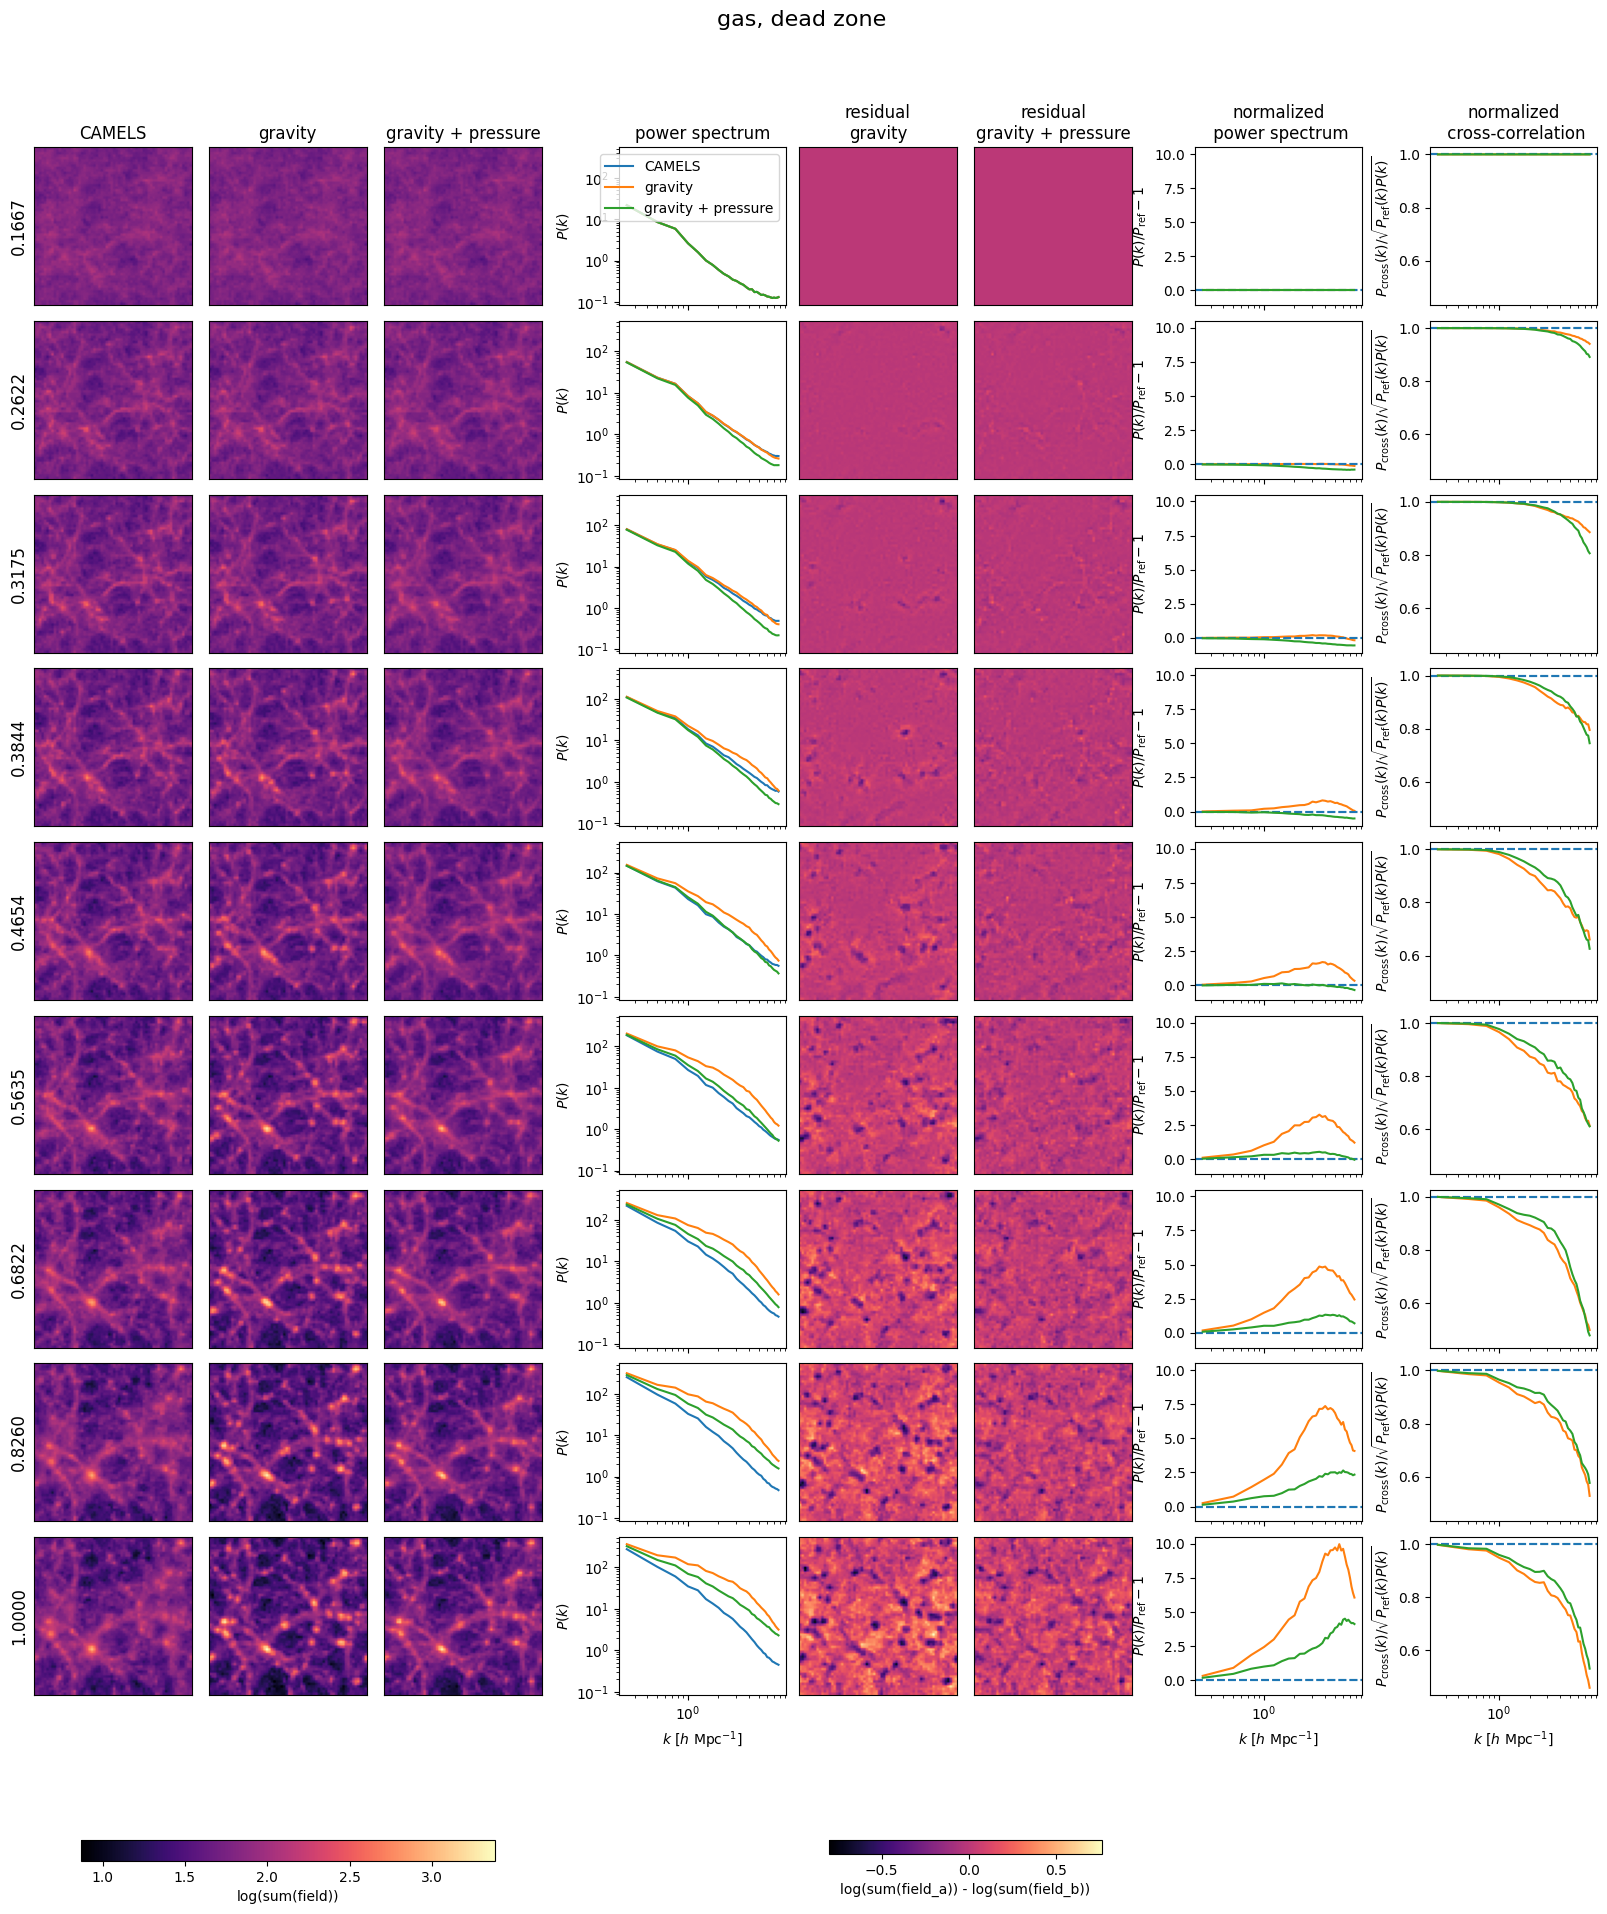

In [30]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([gas_poss, og_gas_poss, nn_gas_poss], axis=0), 
    title=f"gas, {loss_type}",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
)